#### 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### 2. Dataset load

In [2]:
df = pd.read_csv('../Data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

#### 3. Basic understanding

In [3]:
df.shape

(7043, 21)

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.tail(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [6]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5966,8019-ENHXU,Male,0,Yes,No,42,Yes,Yes,Fiber optic,No,...,Yes,Yes,No,Yes,Month-to-month,Yes,Electronic check,99.45,4138.05,Yes
4592,1897-RCFUM,Female,0,Yes,Yes,39,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,24.20,914.6,No
2139,8160-HOWOX,Female,0,No,No,7,Yes,No,DSL,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,66.85,458.1,No
3477,7801-KICAO,Female,0,No,No,18,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,74.15,1345.75,No
1130,5859-HZYLF,Male,0,Yes,Yes,26,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),19.15,515.75,No


In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


#### 4. Missing values

In [10]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [34]:
df[df['TotalCharges'].str.strip() == '']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No,NaN
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No,NaN
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,No,Yes,Yes,Two year,No,Mailed check,80.85,,No,NaN
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No,NaN
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No,NaN
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No,NaN
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No,NaN
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No,NaN
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No,NaN
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,No,Two year,No,Mailed check,73.35,,No,NaN


In [35]:
(df['TotalCharges'].str.strip() == '').sum()

np.int64(11)

In [36]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [37]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [38]:
df[df['TotalCharges'].isnull()][
    ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


### TotalCharges Missing Values

There are 11 records where TotalCharges is missing.
All 11 records have tenure = 0 and Churn = No.
These appear to represent newly joined customers with no accumulated total charges.

In [39]:
df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


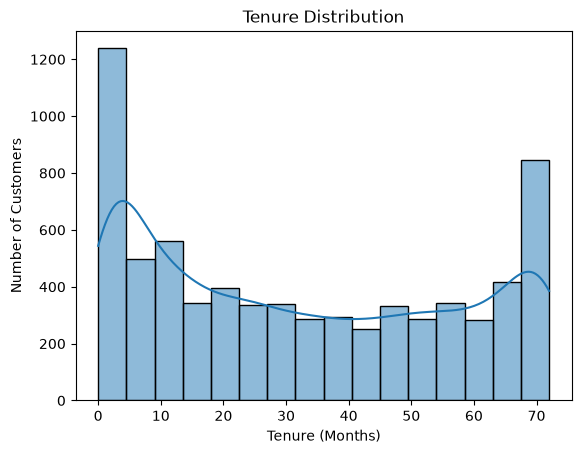

In [47]:
sns.histplot(data=df, x='tenure', kde=True)
plt.title('Tenure Distribution')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

EDA insight:

Customer tenure is distributed across the full service period, with relatively high numbers of customers at very low tenure and near 70+ months.

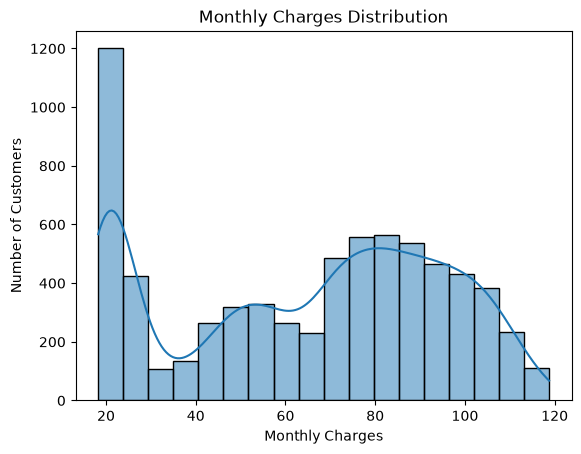

In [48]:
sns.histplot(data=df, x='MonthlyCharges', kde=True)
plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.show()

EDA insight:

Monthly charges show substantial variation, with customers concentrated in both lower-charge and medium-to-high-charge ranges

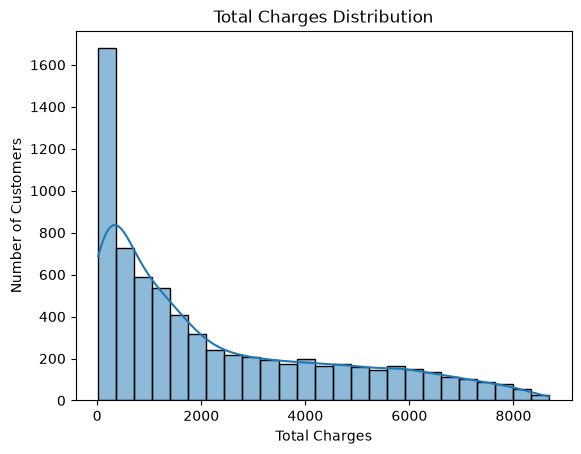

In [49]:
sns.histplot(data=df, x='TotalCharges', kde=True)
plt.title('Total Charges Distribution')
plt.xlabel('Total Charges')
plt.ylabel('Number of Customers')
plt.show()

Total charges are strongly right-skewed, with many customers having relatively low accumulated charges and fewer customers having very high total charges.

### Tenure vs Churn

Churned customers generally have lower tenure than non-churned customers.
The median tenure of churned customers is substantially lower, indicating that
early-stage customers may show higher churn tendency.

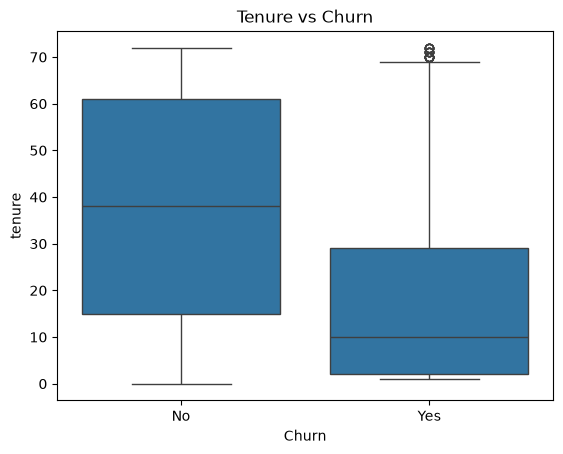

In [50]:
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Tenure vs Churn')
plt.show()

### Monthly Charges vs Churn

Churned customers generally have higher monthly charges than non-churned
customers. This suggests that monthly charges may be associated with churn.

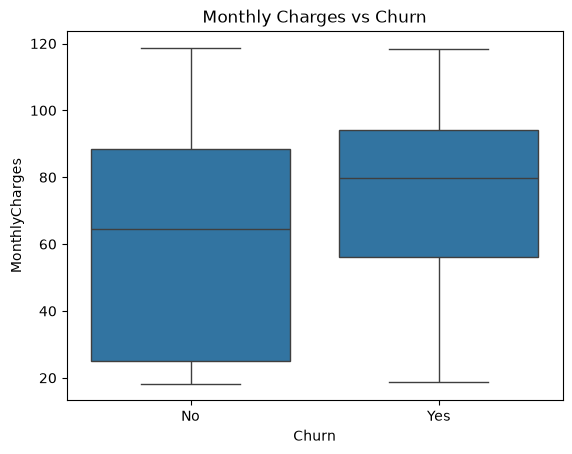

In [45]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges vs Churn')
plt.show()

### Total Charges vs Churn

Churned customers generally have lower total charges than non-churned
customers. This may be related to their shorter tenure, since customers
who leave earlier have less time to accumulate total charges.

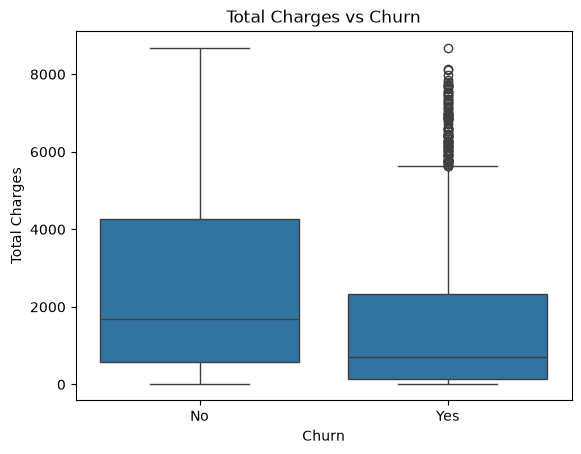

In [51]:
sns.boxplot(data=df, x='Churn', y='TotalCharges')

plt.title('Total Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Total Charges')
plt.show()

#### contract Vs churn ***

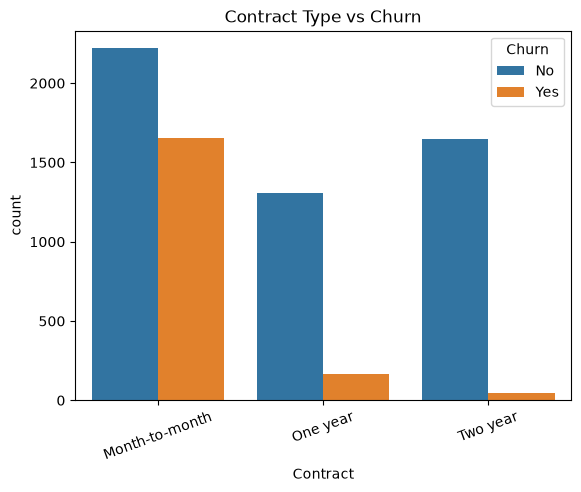

In [52]:
sns.countplot(data=df, x='Contract', hue='Churn')

plt.title('Contract Type vs Churn')
plt.xticks(rotation=20)
plt.show()

In [56]:
pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


Insight:

Month-to-month contract customers have a much higher observed churn rate than customers on one-year or two-year contracts.

#### 2. Internet Service vs Churn

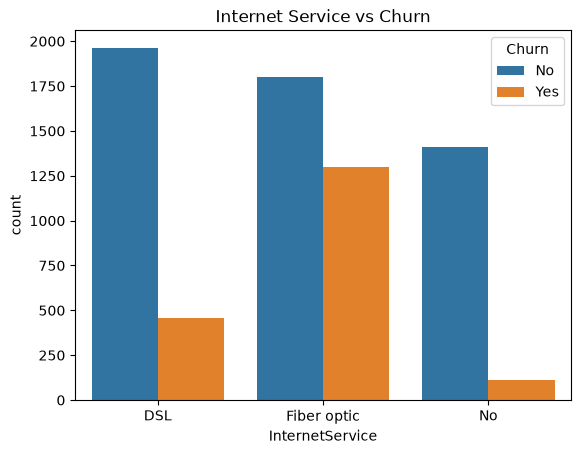

In [53]:
sns.countplot(data=df, x='InternetService', hue='Churn')

plt.title('Internet Service vs Churn')
plt.show()

In [57]:
pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


Insight:

The observed churn rate differs substantially across internet-service categories, with Fiber optic customers showing a higher churn rate in this dataset.

#### 3. Payment Method vs Churn

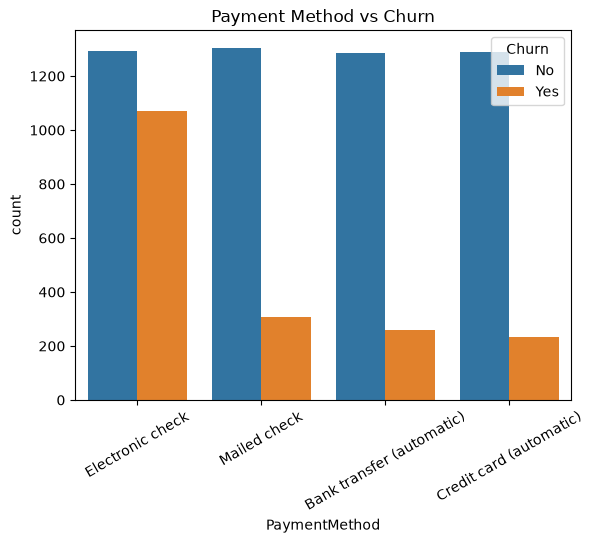

In [54]:
sns.countplot(data=df, x='PaymentMethod', hue='Churn')

plt.title('Payment Method vs Churn')
plt.xticks(rotation=30)
plt.show()

In [58]:
pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


Insight:

Electronic-check customers have the highest observed churn rate among the payment-method categories.

#### 4. Tech Support vs Churn

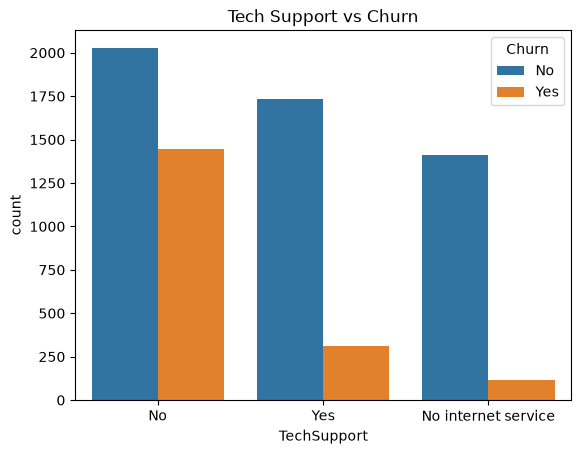

In [55]:
sns.countplot(data=df, x='TechSupport', hue='Churn')

plt.title('Tech Support vs Churn')
plt.show()

In [59]:
pd.crosstab(
    df['TechSupport'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


Insight:

Customers without tech support have a substantially higher observed churn rate than customers with tech support.

Again, association ≠ causation.

In [60]:
def churn_rate_by_column(df, column):
    result = pd.crosstab(
        df[column],
        df['Churn'],
        normalize='index'
    ) * 100
    
    return result

In [62]:
categorical_cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'StreamingTV',
    'StreamingMovies',
    'PaperlessBilling',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines'
]

In [63]:
for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(churn_rate_by_column(df, col))


===== OnlineSecurity =====
Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194

===== OnlineBackup =====
Churn                       No        Yes
OnlineBackup                             
No                   60.071244  39.928756
No internet service  92.595020   7.404980
Yes                  78.468506  21.531494

===== DeviceProtection =====
Churn                       No        Yes
DeviceProtection                         
No                   60.872375  39.127625
No internet service  92.595020   7.404980
Yes                  77.497936  22.502064

===== StreamingTV =====
Churn                       No        Yes
StreamingTV                              
No                   66.476868  33.523132
No internet service  92.595020   7.404980
Yes                  69.929812  30.070188

===== StreamingMovies =====
Churn                 

## Categorical Feature Insights

- Customers without OnlineSecurity show a higher observed churn rate than
  customers with OnlineSecurity.

- Customers without OnlineBackup or DeviceProtection also show higher
  observed churn rates.

- PaperlessBilling shows a noticeable difference in churn rates, with
  paperless-billing customers having a higher observed churn rate.

- Customers with Partners or Dependents show lower observed churn rates
  compared with customers without them.

- PhoneService and MultipleLines show relatively smaller differences in
  observed churn rates.

- These findings represent associations in the dataset and do not establish
  causal relationships.

#### 5. Duplicate records

In [11]:
df.duplicated().sum()

np.int64(0)

#### 6. Unique values

In [12]:
df.nunique().sort_values()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
MultipleLines          3
TechSupport            3
StreamingTV            3
OnlineBackup           3
DeviceProtection       3
StreamingMovies        3
Contract               3
OnlineSecurity         3
InternetService        3
PaymentMethod          4
tenure                73
MonthlyCharges      1585
TotalCharges        6531
customerID          7043
dtype: int64

In [13]:
list = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod',
    'Churn'
]

for col in list:
    print(f"\n===== {col} =====")
    print(df[col].value_counts())


===== gender =====
gender
Male      3555
Female    3488
Name: count, dtype: int64

===== Partner =====
Partner
No     3641
Yes    3402
Name: count, dtype: int64

===== Dependents =====
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

===== PhoneService =====
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

===== MultipleLines =====
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

===== InternetService =====
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

===== OnlineSecurity =====
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

===== OnlineBackup =====
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

===== DeviceProtection =====
DeviceProtection
No                     3095
Yes           

#### 7. Target variable — Churn

In [14]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [15]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

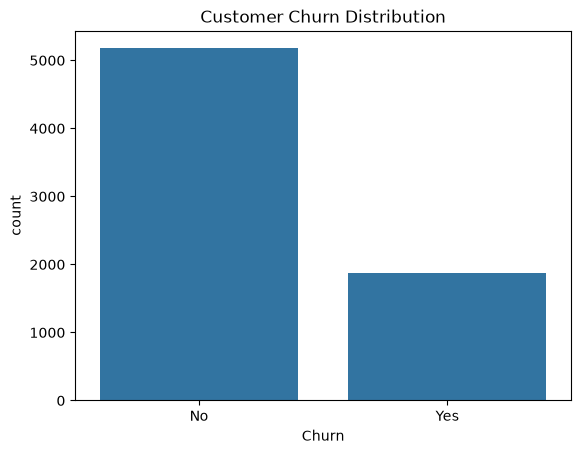

In [16]:
sns.countplot(data=df, x='Churn')
plt.title('Customer Churn Distribution')
plt.show()

#### 8. Numerical columns analysis

In [17]:
df[['SeniorCitizen', 'tenure', 'MonthlyCharges']].describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


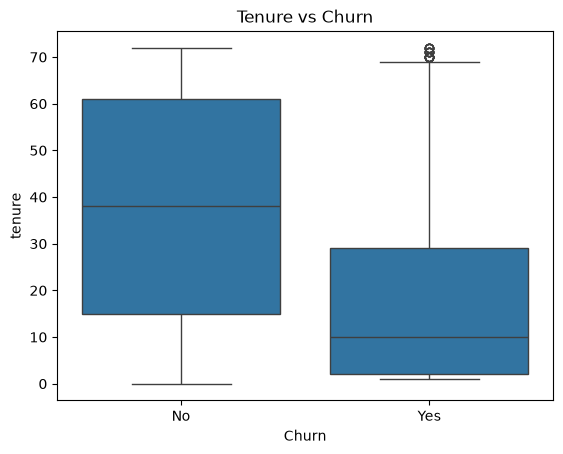

In [41]:
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Tenure vs Churn')
plt.show()

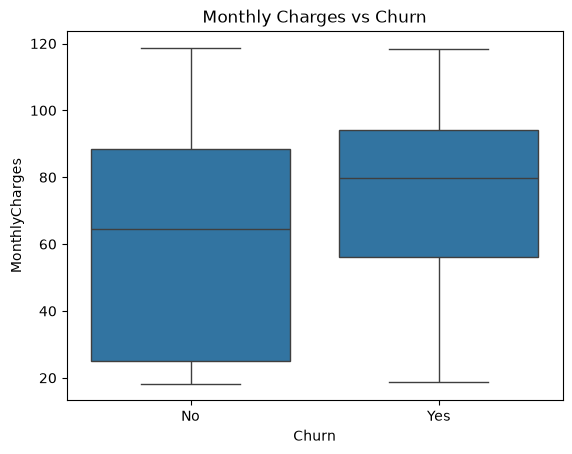

In [42]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges vs Churn')
plt.show()

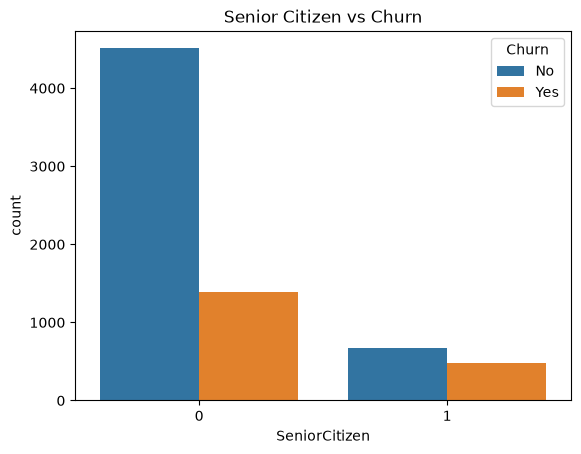

In [43]:
sns.countplot(data=df, x='SeniorCitizen', hue='Churn')
plt.title('Senior Citizen vs Churn')
plt.show()

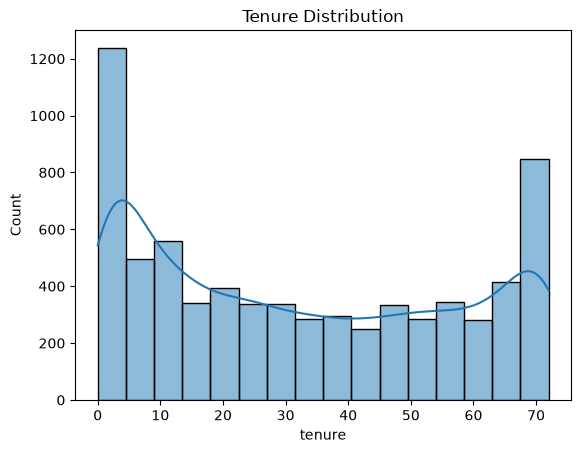

In [18]:
sns.histplot(data=df, x='tenure', kde=True)
plt.title('Tenure Distribution')
plt.show()


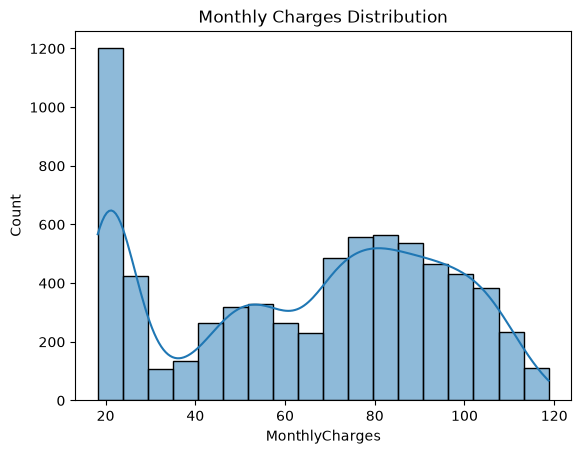

In [19]:
sns.histplot(data=df, x='MonthlyCharges', kde=True)
plt.title('Monthly Charges Distribution')
plt.show()

#### 9. Numerical variable vs Churn

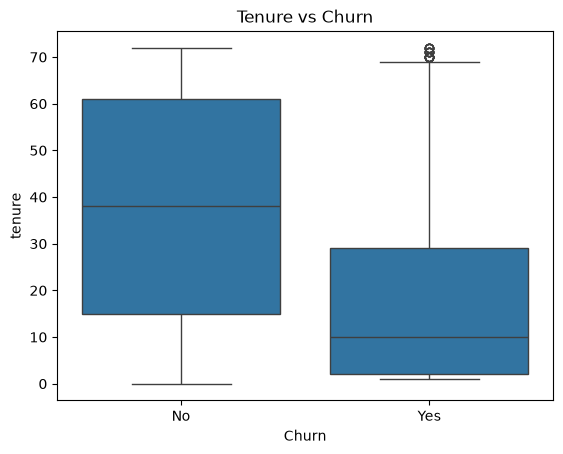

In [20]:
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Tenure vs Churn')
plt.show()

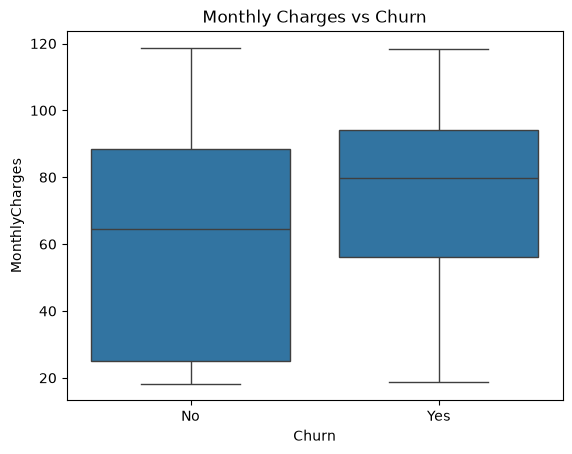

In [21]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges vs Churn')
plt.show()

#### 10. Categorical columns vs Churn

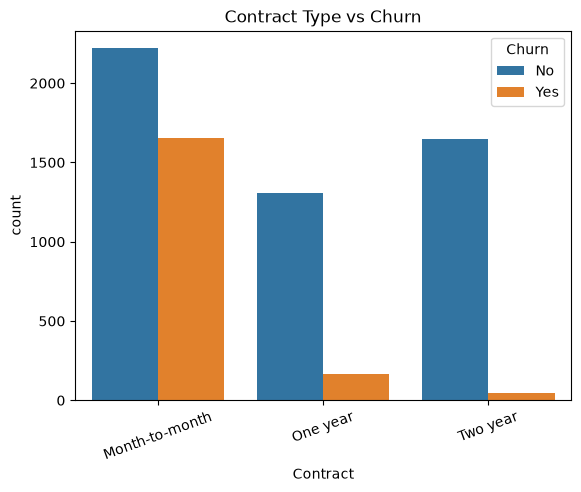

In [22]:
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Contract Type vs Churn')
plt.xticks(rotation=20)
plt.show()

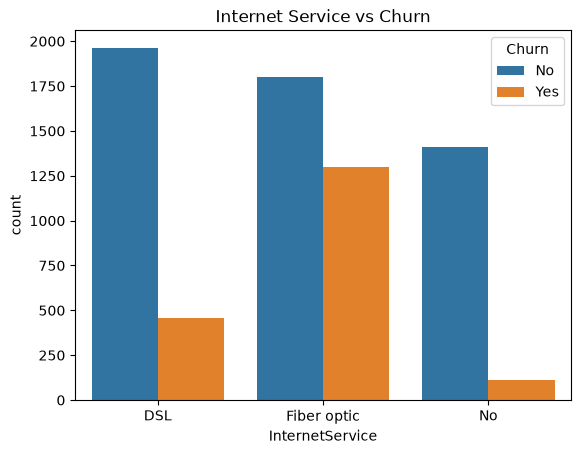

In [23]:
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Internet Service vs Churn')
plt.show()

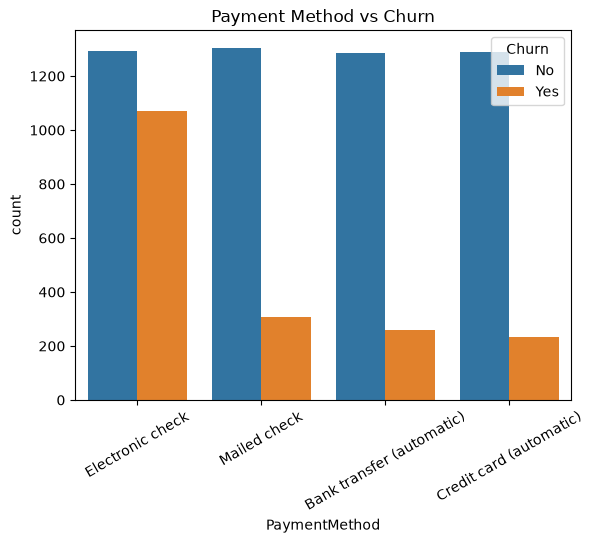

In [24]:
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.title('Payment Method vs Churn')
plt.xticks(rotation=30)
plt.show()

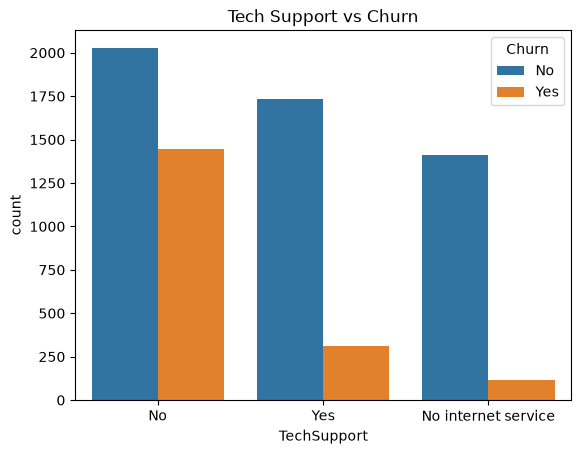

In [25]:
sns.countplot(data=df, x='TechSupport', hue='Churn')
plt.title('Tech Support vs Churn')
plt.show()

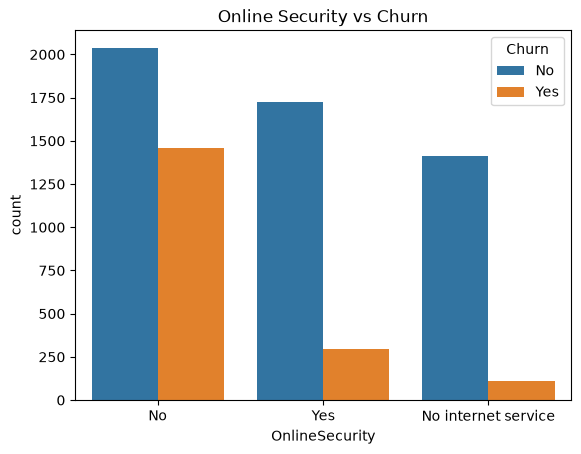

In [26]:
sns.countplot(data=df, x='OnlineSecurity', hue='Churn')
plt.title('Online Security vs Churn')
plt.show()

#### 11. Churn rate by category

In [27]:
pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [28]:
pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [29]:
pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


#### 12. Correlation analysis

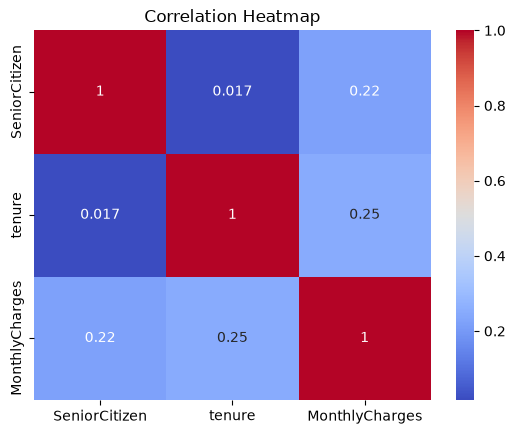

In [30]:
numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges']

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

#### 13. Customer segmentation type analysis

In [31]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12', '13-24', '25-48', '49-72']
)

In [32]:
pd.crosstab(
    df['tenure_group'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
tenure_group,,
0-12,52.321839,47.678161
13-24,71.289062,28.710938
25-48,79.611041,20.388959
49-72,90.486824,9.513176


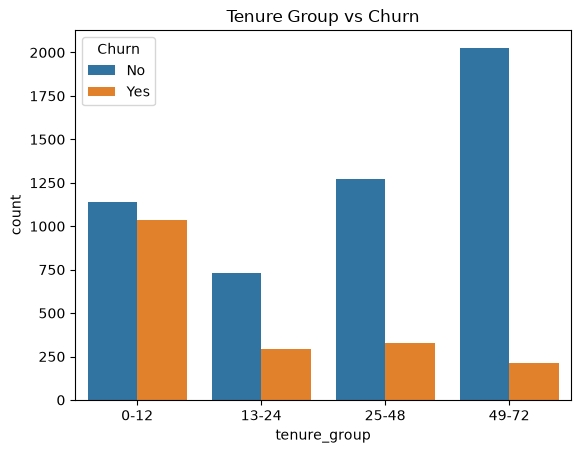

In [33]:
sns.countplot(data=df, x='tenure_group', hue='Churn')
plt.title('Tenure Group vs Churn')
plt.show()